# Binary Mask Segmentation
- **Author:** Juan Pablo Triana Martinez
- **Date:** 2026-03-31

This notebook is a step-by-step process in order to read from `models` folder, a specific desired **binary test** region model, and then proceed to implement from `src/utils`, the necessary text evaluation metrics.

The following are presented in this notebook:
- Read a specific existing subset dataset.
- Obtain the test `torch.utils.DataLoader` from `src/data` of the subset dataset
- Let's load the desired binary model.
- Batch binary hard metrics from `get_binary_metrics()`, which include:
    * accuracy
    * precision
    * recall
    * f1_score
    * iou_pixel
    * dice_pixel
- Scatter plots of each of them to see the values.
- Average of said `get_binary_metrics()`
- Batch binary soft metrics from `binary_soft_metrics()` which include:
    * IoU_region
    * DsC_region
- Scatter plots of each of them to see the values
- Average of said `binary_soft_metrics()`.

The purpose of this notebook is to use it as a tool, to visualize the results of different binary models. 

The objective is to perform the following experiments:

| weight_ce | weight_dice | Rationale |
|--------|----------|--------------|
| 1.0 | 0.0 | Baseline - pure  BCE. no Dice |
| 1.0 | 0.25 | Light Dice regularization |
| 1.0 | 0.5  | Balanced towards BCE (your default) |
| 1.0 | 0.75 | BCE + Dice - dominant |
| 1.0 | 1.0  | Equal - weighting |

After doing this, we will see the following as well:
| weight_ce | weight_dice | Rationale |
|--------|----------|--------------|
| 0.0 | 1.0 | Baseline - pure  Dice. no BCE/CE |
| 0.25 | 1.0 | Light BCE regularization |
| 0.5 | 1.0  | Balanced towards Dice (your default) |
| 0.75 | 1.0 | Dice + BCE - dominant |

## 1. Read a specific subset dataset

In [1]:
from pathlib import Path
import sys
import torch
from torchvision import transforms
from typing import Dict

In [2]:
# Resolve the project root and add it to the module search path
working_path = Path().cwd().parent
sys.path.insert(0, str(working_path))

In [3]:
from src.data import get_dataloaders_text_detection

In [4]:
DATA_PATH = working_path / "data"
SUBSET_DATANAME= "doclaynet_20_percent_seed_7"

In [5]:
# Let's define the transforms to avoid so much time wasted for calculating std and mean per channel
# NOTE: Mimicking the same transform when trained

# Found empirically from 20% of the dataset
mean = [0.9329, 0.9343, 0.9341]
std = [0.1651, 0.1592, 0.1623]
new_height = 512
new_width = 512

train_transform = transforms.Compose([
    transforms.Resize((new_height, new_width)),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1,
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

# Val and test share the same no-augmentation pipeline
inference_transform = transforms.Compose([
    transforms.Resize((new_height, new_width)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
    ])


In [6]:
# Default settings from training scripts
BATCH_SIZE = 8
NEW_HEIGHT = 512
NEW_WIDTH = 512
NUM_WORKERS = 0
PIN_MEMORY = False

# NOTE: linknet_binary_v1_1.pth was trained without input normalization.
# Passing explicit transforms to match the original training setup so that
# model predictions remain correct. For NEW models trained with normalization,
# remove these explicit transforms and let the dataloader auto-compute them.
# train_transform = transforms.Compose([
#     transforms.Resize((NEW_HEIGHT, NEW_WIDTH)),
#     transforms.ToTensor(),
# ])
# inference_transform = transforms.Compose([
#     transforms.Resize((NEW_HEIGHT, NEW_WIDTH)),
#     transforms.ToTensor(),
# ])

binary_train_dl, binary_val_dl, binary_test_dl = get_dataloaders_text_detection(
    data_path=DATA_PATH,
    dataset_name=SUBSET_DATANAME,
    mask_type="binary-text",
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    new_height=NEW_HEIGHT,
    new_width=NEW_WIDTH,
    train_transform=train_transform,
    val_transform=inference_transform,
    test_transform=inference_transform,
)

## 2. Let's load a binary model

In [7]:
# Model name, this can change many times.
model_name = "linknet_binary_doclaynet_20_percent_seed_7_ce_0.25_dice_1.0_.pth"
model_path = working_path / "models" / model_name
model_path.exists()

True

In [8]:
from src.models import LinknetModel

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"
binary_text_model = LinknetModel(Cin=3, N = 1).to(device)

In [10]:
# Let's load the trained google collab model
binary_text_model.load_state_dict(torch.load(f = model_path, map_location=device))

<All keys matched successfully>

## 3 & 4 Let's obtain the binary metrics, across All the images
For this we will be using the following:
1. `get_binary_metrics()` function from `src/utils/text_detection_eval_metrics.py`.
2. `get_soft_metrics()` with `is_binary = True`, in order to obtain the total semantic metrics.

These functions are set in a way that are used across batches. However, we can create a new function that we are gonna call `get_images_metrics`, which will iterate across each batch, and compare and get per image metrics.

In [11]:
# Imports for all nce
from src.utils import get_binary_metrics, get_soft_metrics
from collections import defaultdict
from torch.utils.data import DataLoader
from typing import Tuple, List
from tqdm import tqdm
import torch.nn as nn

def get_images_metrics(
        dataloder: DataLoader,
        model: nn.Module) -> Dict[str, list]:
    
    # Let's now define the total_metrics dictionary
    total_metrics: Dict[str, list] = defaultdict(list)

    # Let's set the model to eval mode
    model.eval()

    # Let's use torch.infetence_mode() to not keep gradients, and fast inference
    with torch.inference_mode():
        for batch, (X_imgs, X_masks, X_metadata) in tqdm(enumerate(binary_test_dl), desc= "Iterating across batches...", total=len(dataloder)):
            # Get the images and masks to perform analysis
            X_imgs = X_imgs.to(device)
            X_masks = X_masks.to(device)

            # Get the logits of the model 
            X_logits = model(X_imgs)

            # Now let's iterate across each image
            for b in range(X_logits.shape[0]):

                # Let's get the rest of the logits
                X_logits_b = X_logits[b:b+1]
                X_masks_b = X_masks[b:b+1]
                X_metadata_b = X_metadata["file_name"][b]
                X_imgs_b = X_imgs[b]

                # Let's get the pixel metrics and soft binary metrics
                pixel_metrics_b = get_binary_metrics(X_logits_b, X_masks_b)
                region_metrics_b = get_soft_metrics(X_logits_b, X_masks_b, is_binary=True)

                # Append all the soft and hard pixel metrics
                for k, v in pixel_metrics_b.items():
                    total_metrics[k].append(float(v))
                for k, v in region_metrics_b.items():
                    total_metrics[k].append(float(v.mean()))

                # Now let's append the names of the files
                total_metrics["files_names"].append(X_metadata_b)

                # Now let's append the imgs, logits, masks
                total_metrics["imgs"].append(X_imgs_b)
                total_metrics["masks"].append(X_masks_b)
                total_metrics["logits"].append(X_logits_b)

    return total_metrics

In [12]:
total_metrics = get_images_metrics(
    dataloder=binary_test_dl,
    model=binary_text_model)

Iterating across batches...: 100%|██████████| 125/125 [03:17<00:00,  1.58s/it]


## 4.1 Plot all of the total metrics: Hard + soft pixel metrics.

In [13]:
import matplotlib.pyplot as plt
import numpy as np

def plot_metrics_per_sample(metrics_dict: Dict[str, np.ndarray], title: str = "") -> None:
    """Line plot of each metric across the batch dimension."""
    n = len(metrics_dict)
    fig, axs = plt.subplots(nrows=n, ncols=1, figsize=(n, 2 * n))
    if n == 1:
        axs = [axs]
    for ax, (name, values) in zip(axs, metrics_dict.items()):
        ax.plot(values, marker="o")
        ax.set_title(name)
        ax.set_xlabel("Sample index")
        ax.set_ylabel("Value")
        ax.set_ylim(0, 1.05)
    if title:
        fig.suptitle(title, y=1.01)
    plt.tight_layout()
    plt.show()

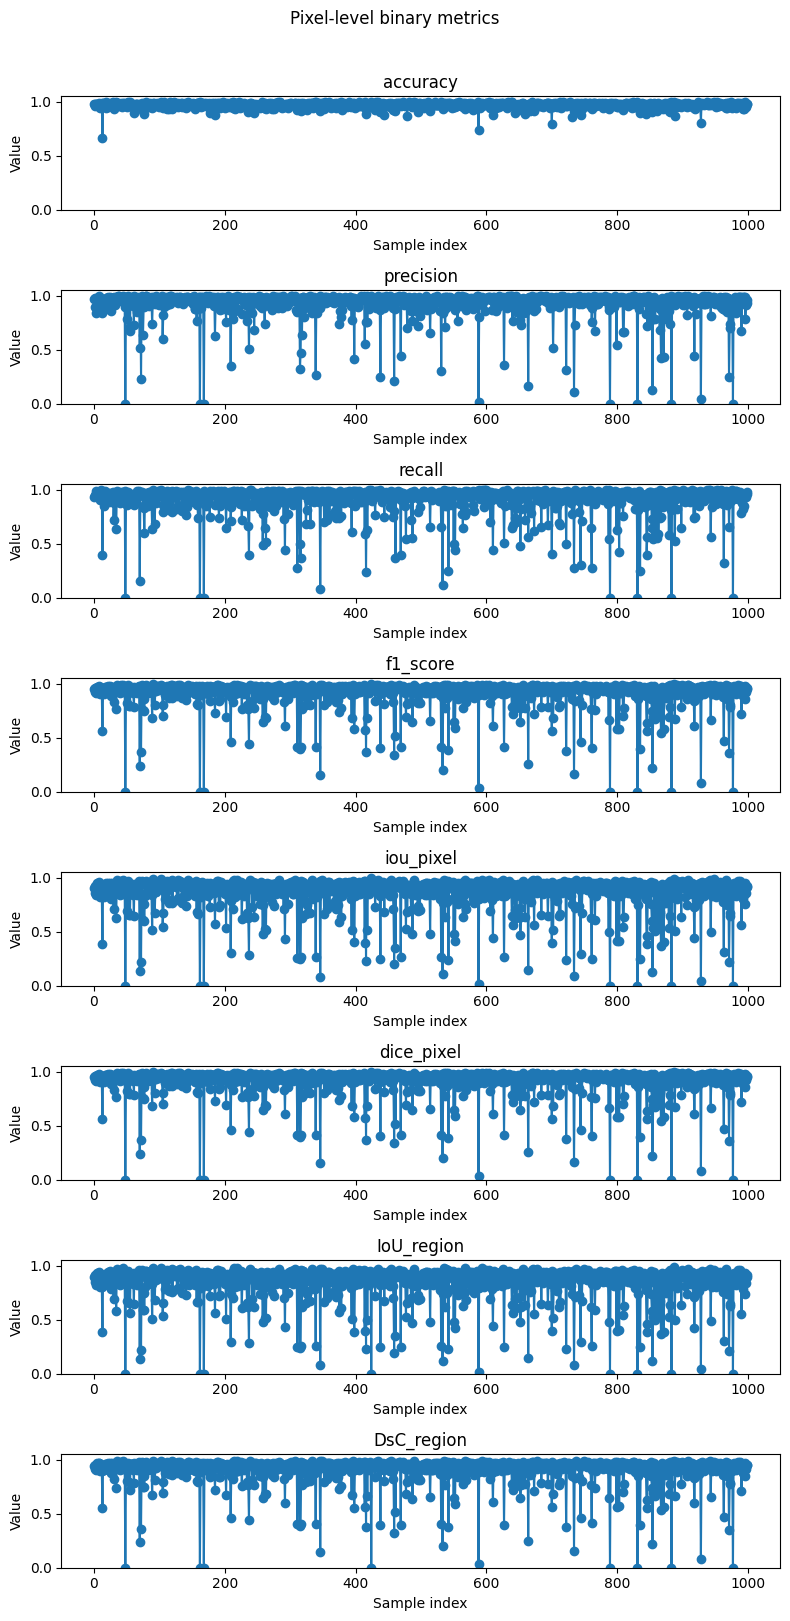

In [14]:
# Let's get all metrics without file_names
numeric_metrics = {key:val for key, val in total_metrics.items() if key not in ["files_names", "imgs", "masks", "logits"]}
plot_metrics_per_sample(numeric_metrics, title="Pixel-level binary metrics")

## 5. Let's get the average of the binary metrics
Now let's get the average of the total binary numeric metrics!

In [19]:
# Let's get the average metrics
average_metrics = {k : round(np.mean(np.array(v, dtype=np.float32)).item(), 5) for k, v in numeric_metrics.items()}
average_metrics

{'accuracy': 0.96957,
 'precision': 0.92197,
 'recall': 0.90036,
 'f1_score': 0.90313,
 'iou_pixel': 0.84594,
 'dice_pixel': 0.90313,
 'IoU_region': 0.83161,
 'DsC_region': 0.89431}

## 6. Now, let's plot the images with the worst set measurement.
This function will be called `plot_worst_images` which will take the `numeric_metrics` dictionary, and the `average_metrics` dictionary.
Based on setting it to one specific key, it will iterate across all the images and **Only plot the images below the average**.

In [16]:
from PIL import Image
def plot_worst_images(num_metrics: Dict[str, list],
                      avg_metrics: Dict[str, float],
                      total_imgs: List[torch.Tensor],
                      total_masks: List[torch.Tensor],
                      total_logits: List[torch.Tensor],
                      key_metric:str,
                      max_num:int = 20) -> None:
    
    assert key_metric in num_metrics.keys(), "This key metric doesnt exist"

    avg_threshold = avg_metrics[key_metric]
    count_less_metric = 0
    for i, metric in tqdm(enumerate(num_metrics[key_metric]), desc="Iterating across all images...", total=len(num_metrics[key_metric])):
        if metric <= avg_threshold:
            if count_less_metric <= max_num:
                fig, axs = plt.subplots(nrows=1, ncols=3, figsize = (15, 5))

                fig.suptitle(f"{key_metric} figure: {metric:.3f} < avg_threshold: {avg_threshold:.3f}")
                # --- Image ---
                img = total_imgs[i].permute(1, 2, 0).cpu()
                axs[0].imshow(img)
                axs[0].set_title("Image")
                axs[0].axis("off")

                # --- Ground Truth ---
                gt = total_masks[i].squeeze().cpu()
                axs[1].imshow(gt, cmap="gray")
                axs[1].set_title("Ground Truth")
                axs[1].axis("off")

                # --- Prediction ---
                pred = total_logits[i
                                    ].squeeze().cpu()

                # If logits → convert to probabilities / binary
                if pred.max() > 1 or pred.min() < 0:
                    pred = torch.sigmoid(pred)

                pred = (pred > 0.5).float()

                axs[2].imshow(pred, cmap="gray")
                axs[2].set_title("Prediction")
                axs[2].axis("off")
                count_less_metric += 1
                plt.show()
    

In [17]:
average_metrics.keys()

dict_keys(['accuracy', 'precision', 'recall', 'f1_score', 'iou_pixel', 'dice_pixel', 'IoU_region', 'DsC_region'])

Iterating across all images...:   0%|          | 0/1000 [00:00<?, ?it/s]Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.650515..0.4126884].


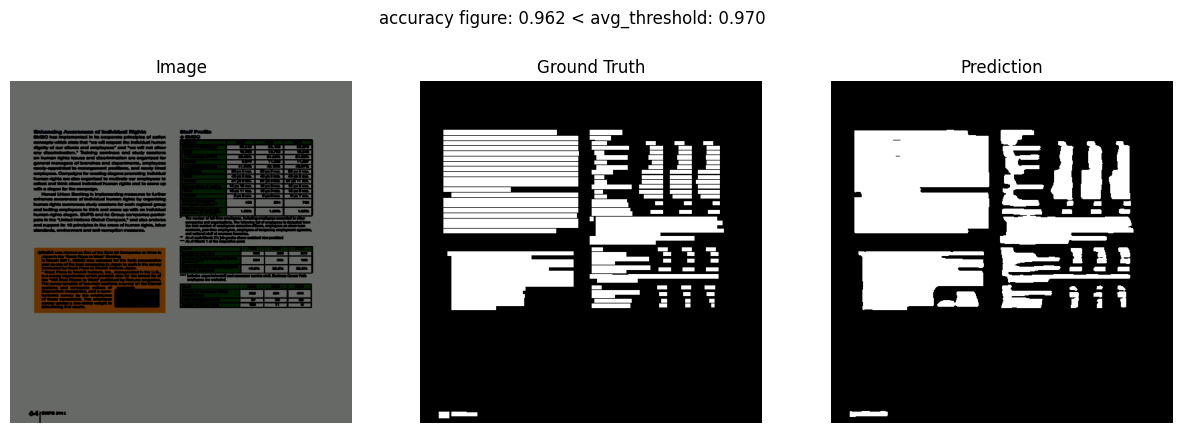

Iterating across all images...:   0%|          | 2/1000 [00:00<02:38,  6.28it/s]Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.2675757..0.4126884].


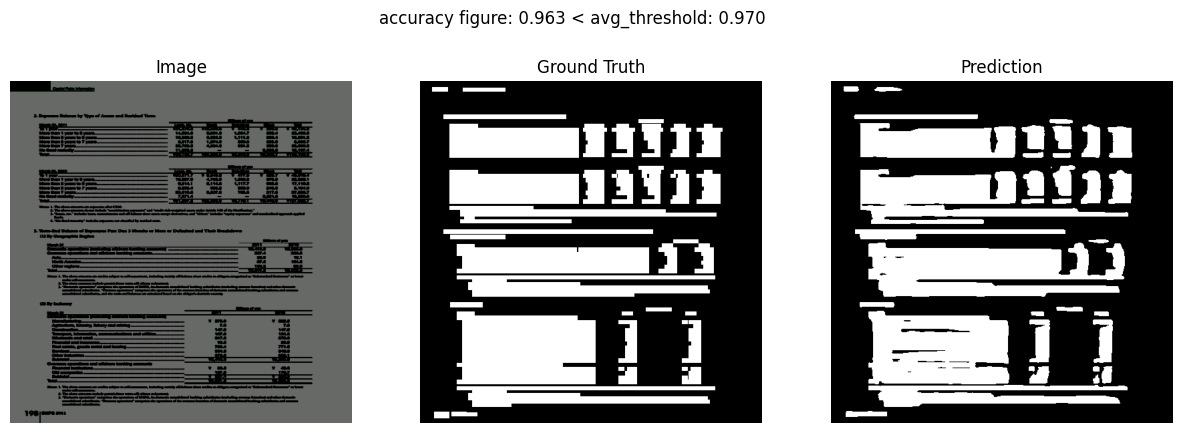

Iterating across all images...:   1%|          | 7/1000 [00:00<01:24, 11.77it/s]Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.0705123..0.4126884].


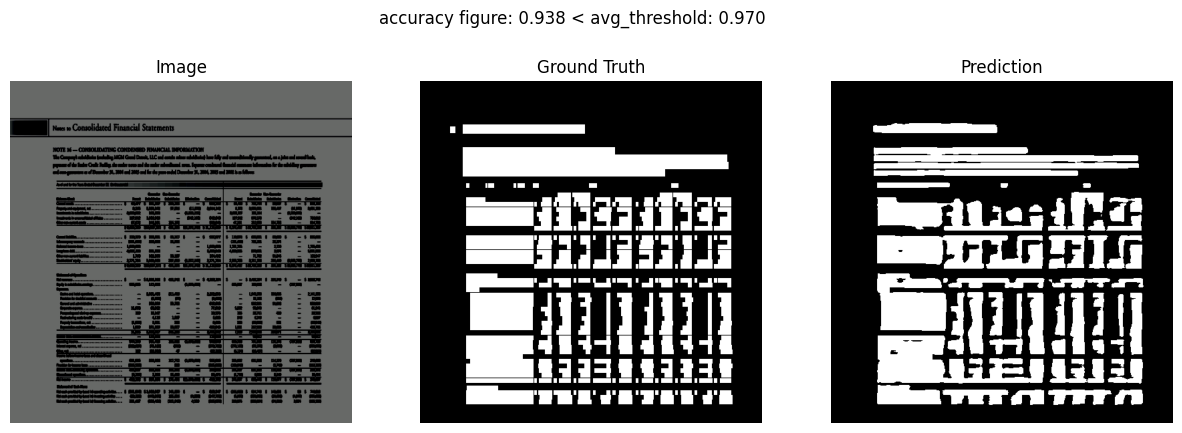

Iterating across all images...:   1%|          | 10/1000 [00:00<01:32, 10.68it/s]Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.119778..0.4126884].


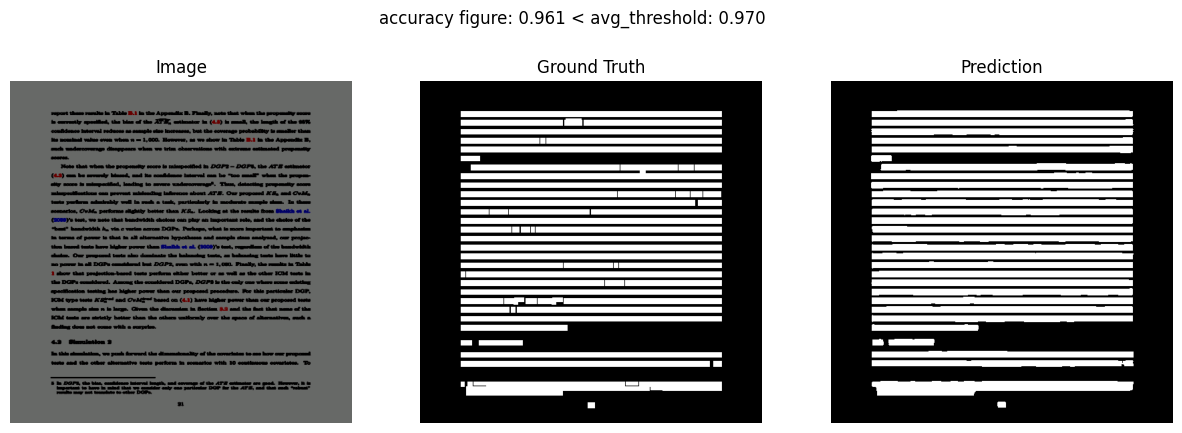

Iterating across all images...:   1%|          | 12/1000 [00:01<01:47,  9.20it/s]Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.34173..0.4126884].


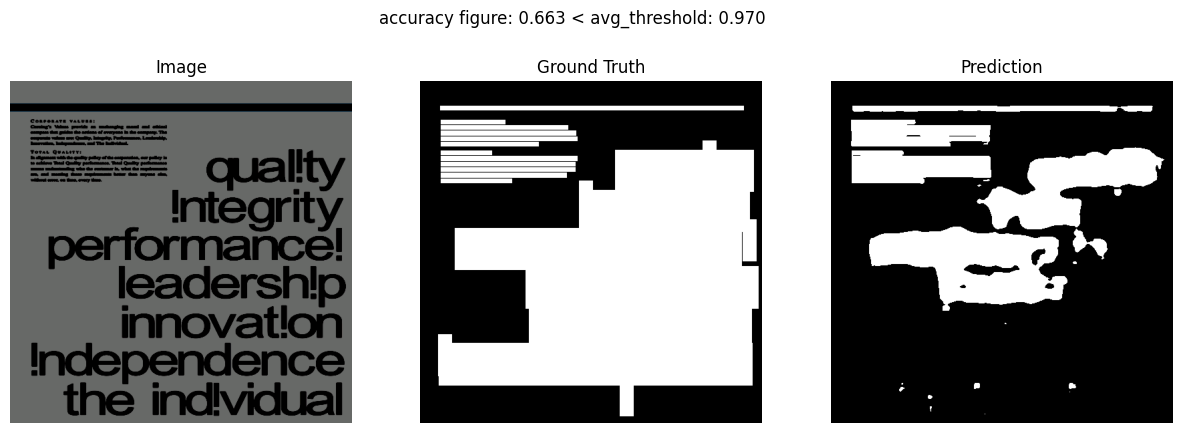

Iterating across all images...:   1%|▏         | 14/1000 [00:01<01:55,  8.57it/s]Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.4499583..0.4126884].


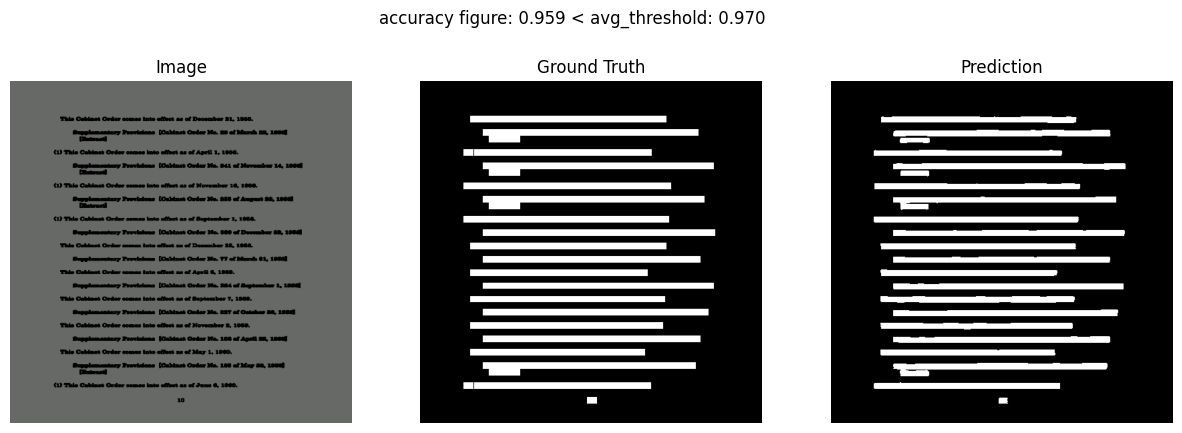

Iterating across all images...:   2%|▏         | 16/1000 [00:01<01:59,  8.25it/s]Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.080464..0.4126884].


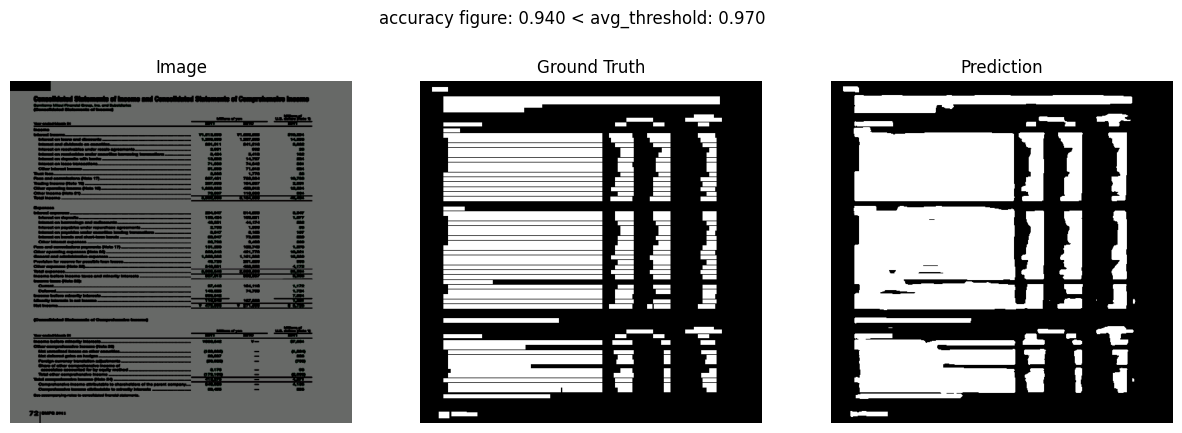

Iterating across all images...:   2%|▏         | 19/1000 [00:02<01:48,  9.05it/s]Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.8687186..0.4126884].


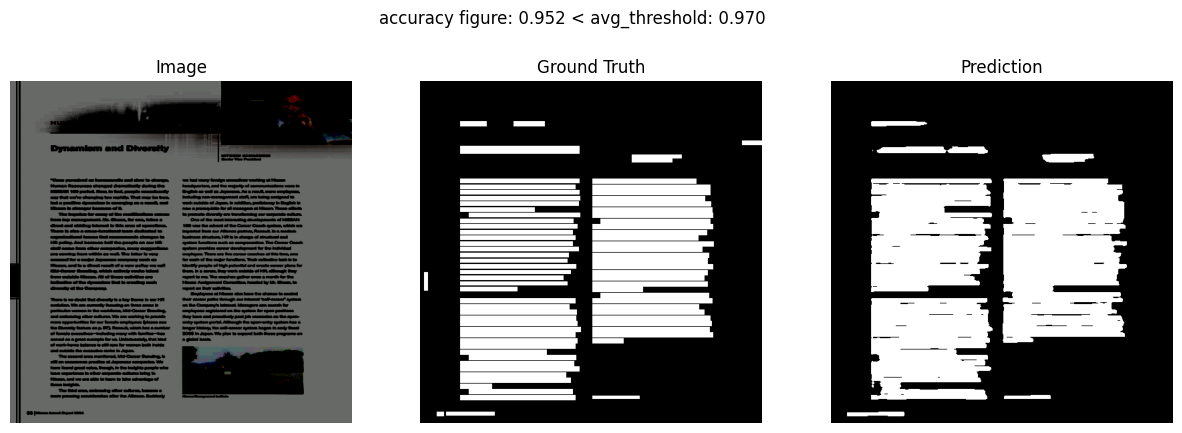

Iterating across all images...:   2%|▏         | 22/1000 [00:02<01:45,  9.28it/s]Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.3204665..0.4126884].


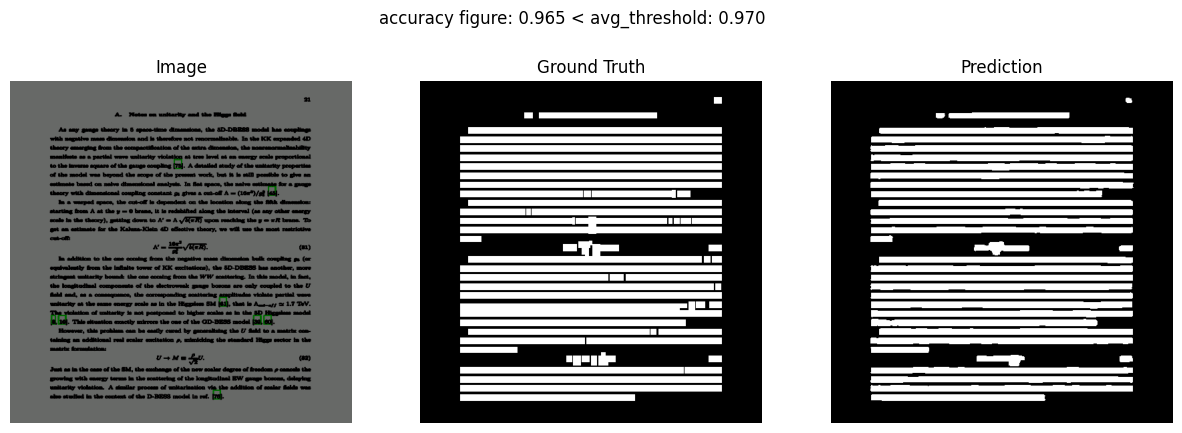

Iterating across all images...:   2%|▎         | 25/1000 [00:02<01:35, 10.21it/s]Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.650515..0.4126884].


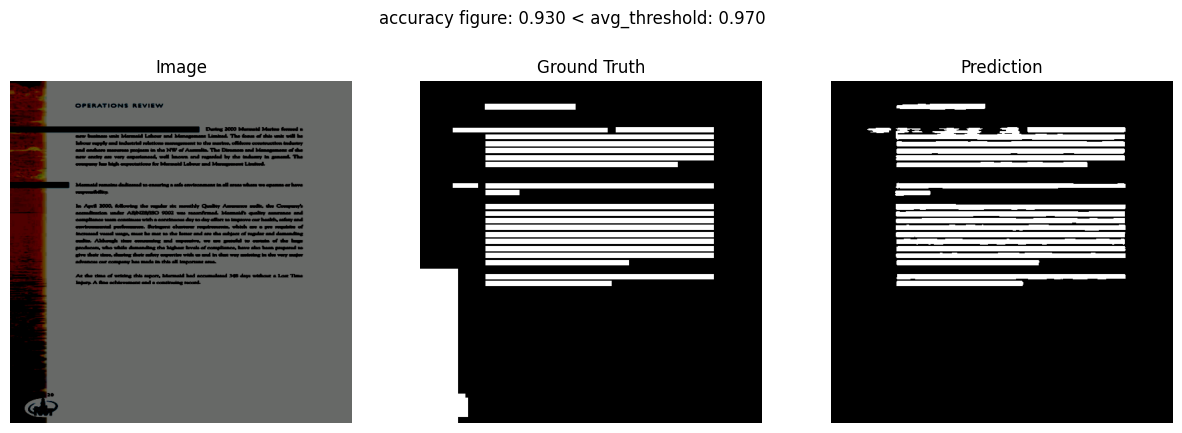

Iterating across all images...:   3%|▎         | 31/1000 [00:02<01:10, 13.68it/s]Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.499224..0.4126884].


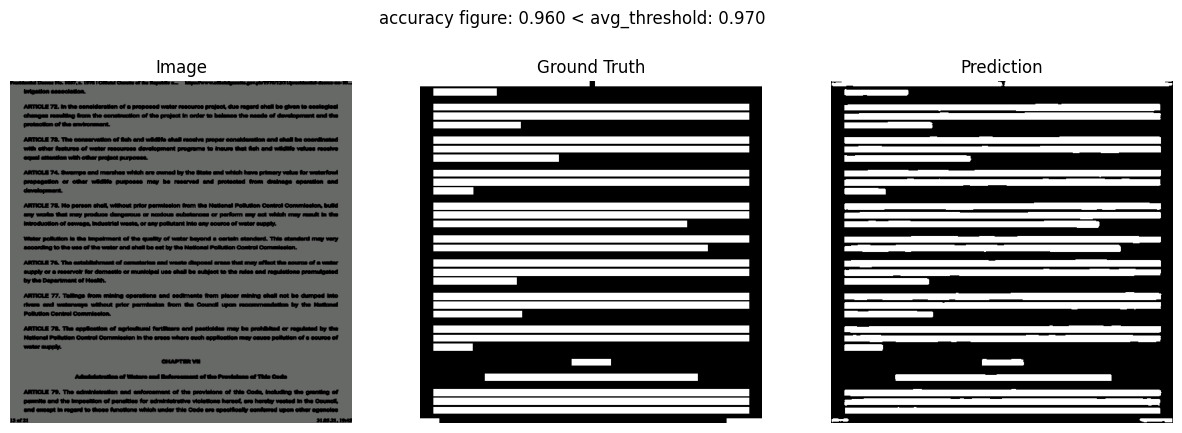

Iterating across all images...:   4%|▍         | 39/1000 [00:03<00:53, 18.01it/s]Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.1543627..0.4126884].


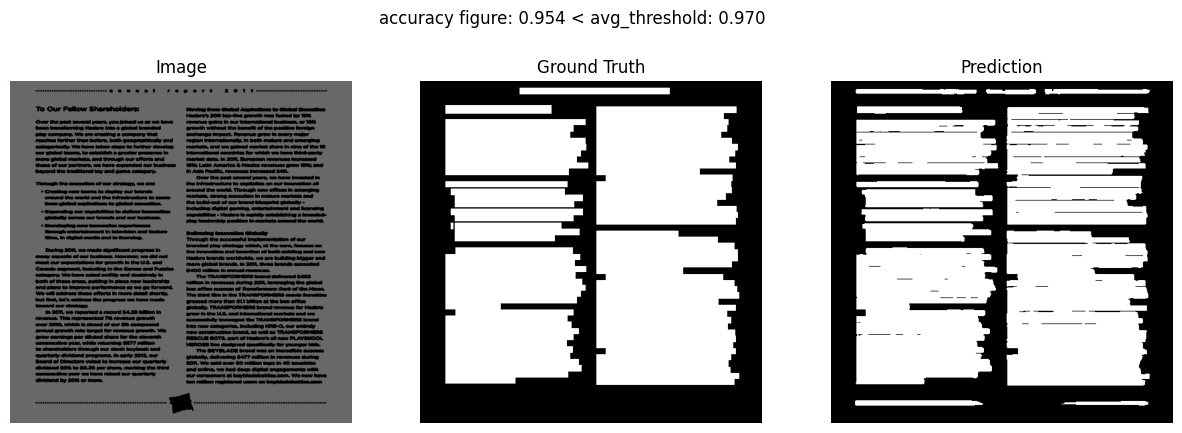

Iterating across all images...:   4%|▍         | 44/1000 [00:03<00:52, 18.30it/s]Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.858767..0.4126884].


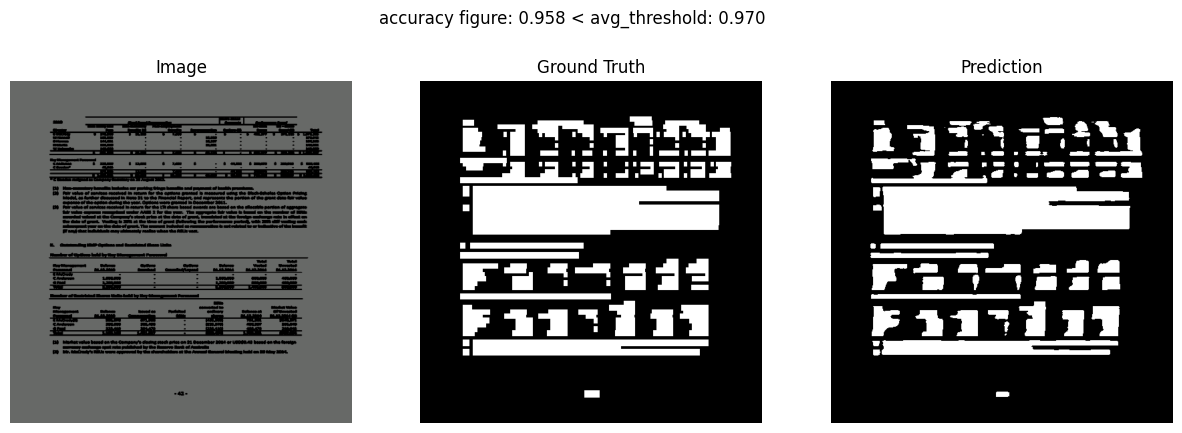

Iterating across all images...:   5%|▌         | 50/1000 [00:03<00:47, 19.94it/s]Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.2467194..0.4126884].


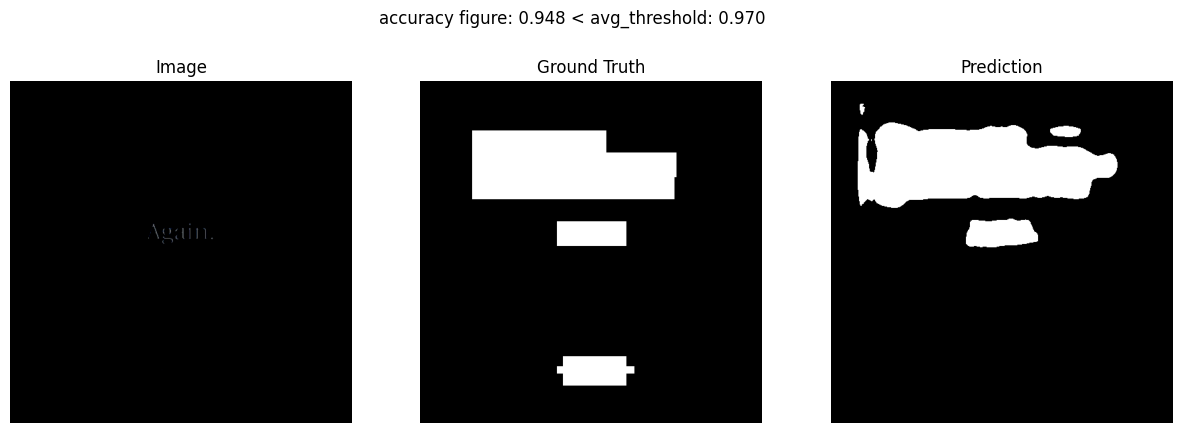

Iterating across all images...:   5%|▌         | 52/1000 [00:03<00:57, 16.50it/s]Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.858767..0.4126884].


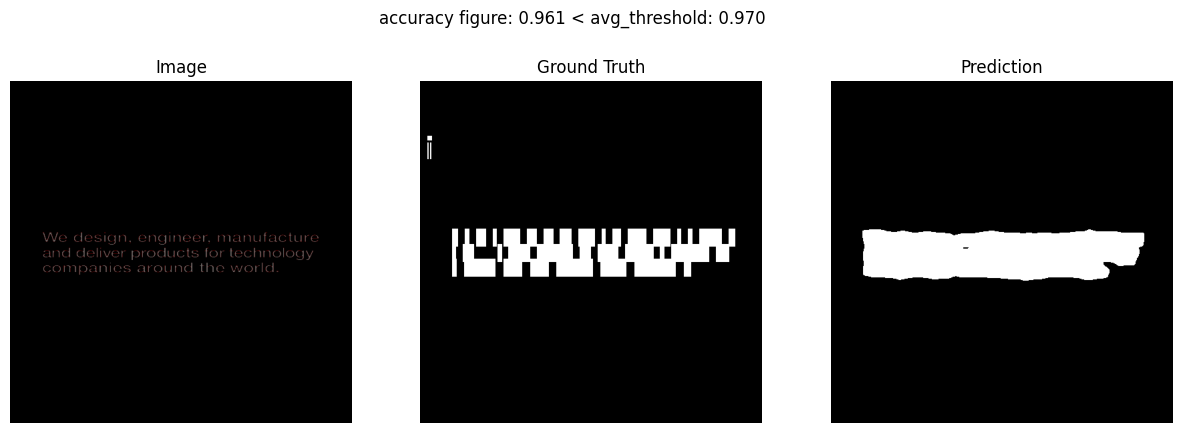

Iterating across all images...:   5%|▌         | 54/1000 [00:04<01:07, 14.02it/s]Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.858767..0.4126884].


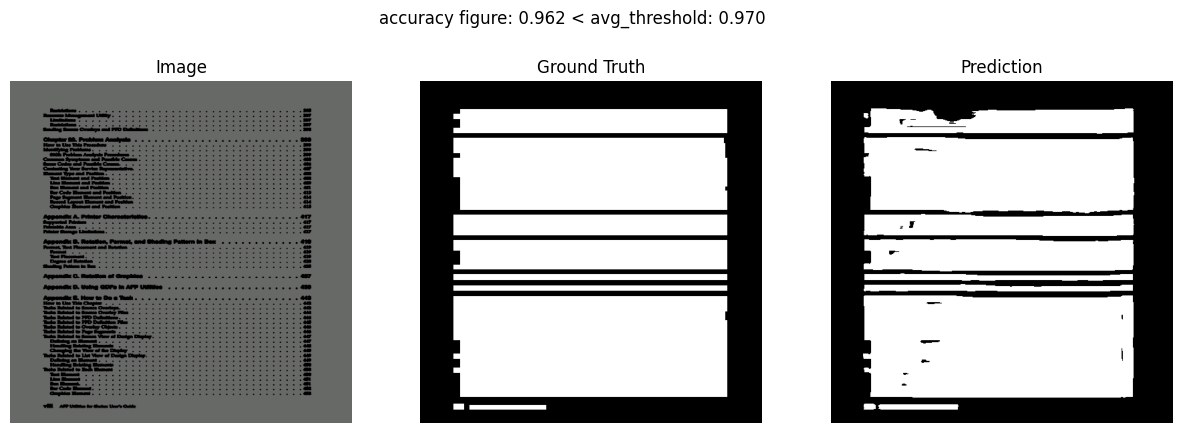

Iterating across all images...:   6%|▌         | 58/1000 [00:04<01:06, 14.17it/s]Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.2282615..0.4126884].


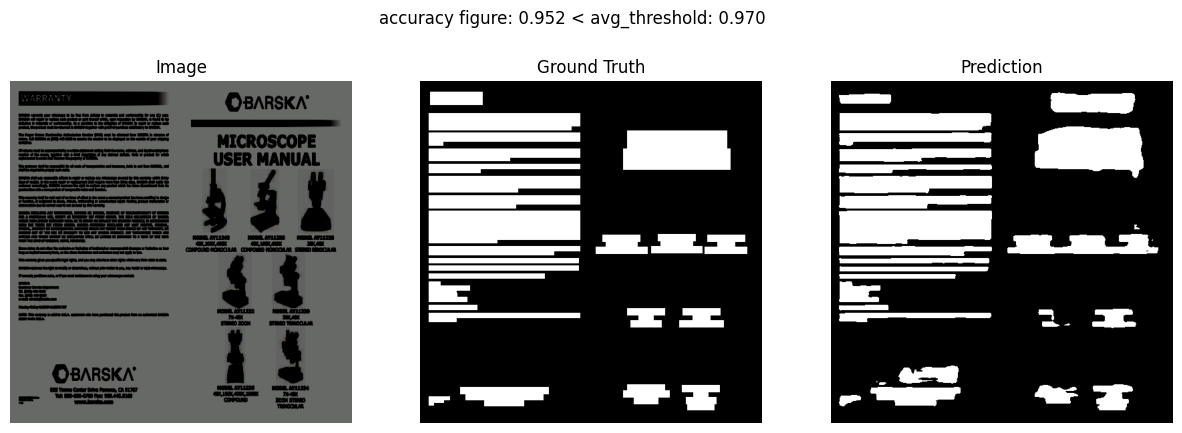

Iterating across all images...:   6%|▌         | 60/1000 [00:04<01:15, 12.42it/s]Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.2775273..0.4126884].


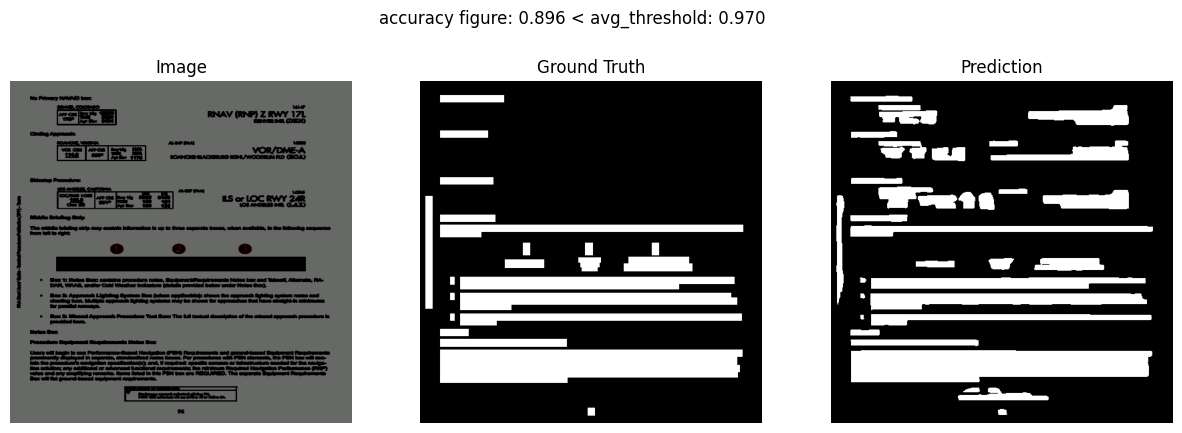

Iterating across all images...:   6%|▌         | 62/1000 [00:04<01:23, 11.19it/s]Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.8241825..0.4126884].


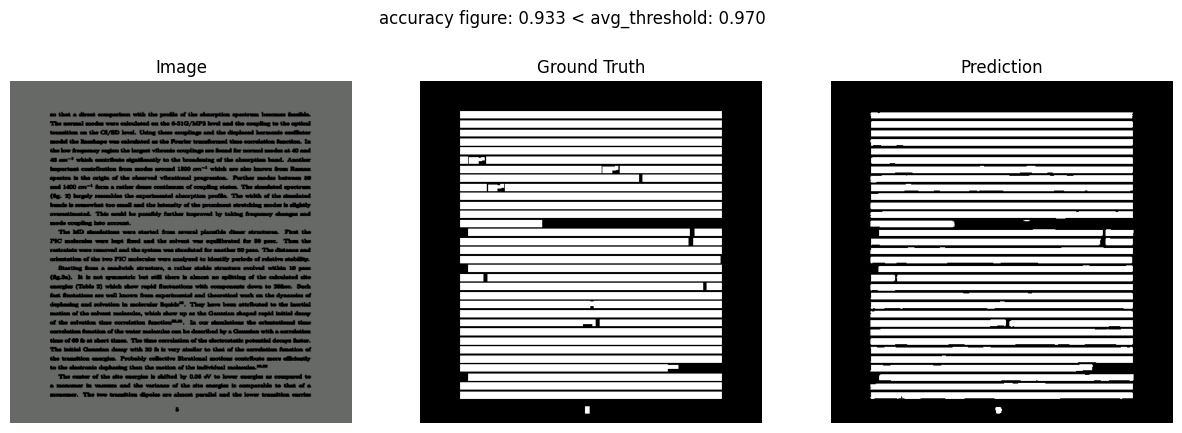

Iterating across all images...:   6%|▋         | 64/1000 [00:05<01:30, 10.33it/s]Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.819453..0.4126884].


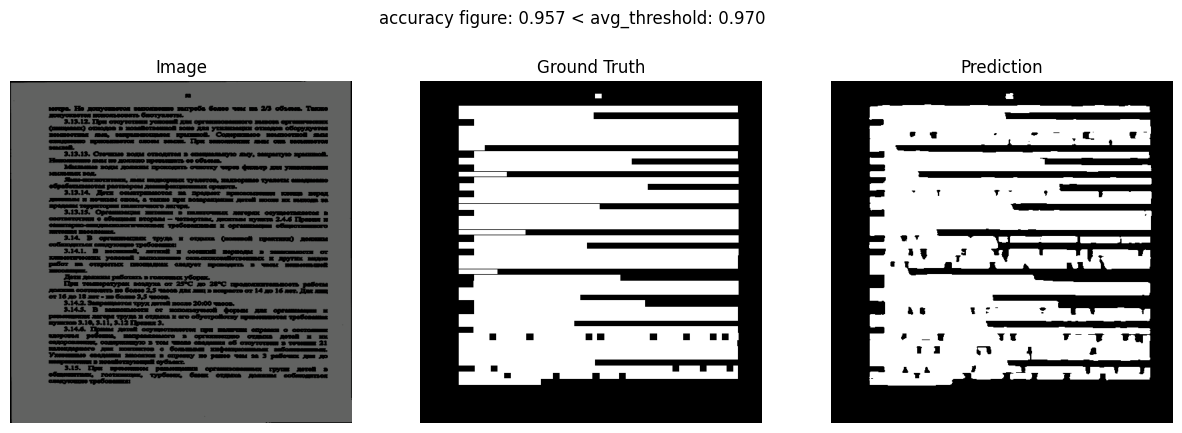

Iterating across all images...:   7%|▋         | 68/1000 [00:05<01:21, 11.44it/s]Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.4006925..0.4126884].


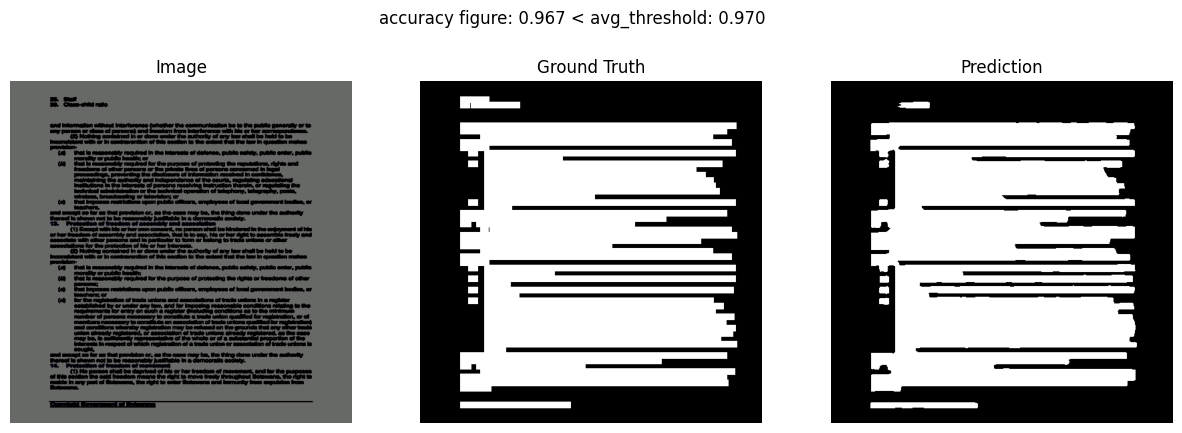

Iterating across all images...: 100%|██████████| 1000/1000 [00:05<00:00, 173.31it/s]


In [18]:
# Let's plot the worst images jejejejje
plot_worst_images(num_metrics=numeric_metrics,
                  avg_metrics=average_metrics,
                  total_imgs=total_metrics["imgs"],
                  total_masks=total_metrics["masks"],
                  total_logits=total_metrics["logits"],
                  key_metric="accuracy",
                  max_num=20)